Exercise 1: Boxex and balls

In [36]:
import numpy as np
#import matplotlib.pyplot as plt
number_of_simulations = 100
box = np.random.rand(number_of_simulations)
ball = np.random.rand(number_of_simulations)

box = np.where(box < 0.4, "Box1", "Box2")


def draw_balls(box, ball):
    results = np.zeros((2, 2), dtype=int)
    for b, bl in zip(box, ball):
        if b == "Box1":
            if bl < 5/8:
                 results[0,0] = results[0,0] + 1
            else:
                results[0,1] = results[0,1] + 1
        else:  # Box2
            if bl < 5/7:
                results[1,0] = results[1,0] + 1
            else:
                results[1,1] = results[1,1] + 1
    return results

results = draw_balls(box, ball)
print(draw_balls(box, ball))

frequency_prob = [sum(results[:,0])/sum(results.flatten()), sum(results[:,1])/sum(results.flatten())]
print(frequency_prob)




        


[[29 13]
 [39 19]]
[0.68, 0.32]


Exercise 2: Weather forcasting

In [55]:
!pip install matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 112.3/112.3 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.3/8.3 MB 38.0 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 293.4/293.4 kB 5.7 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 10.9 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.5/66.5 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 113.9/113.9 kB 3.1 MB/s eta 0:00:00


[[5262 1342]
 [1341 2055]]
0.20308950477055884


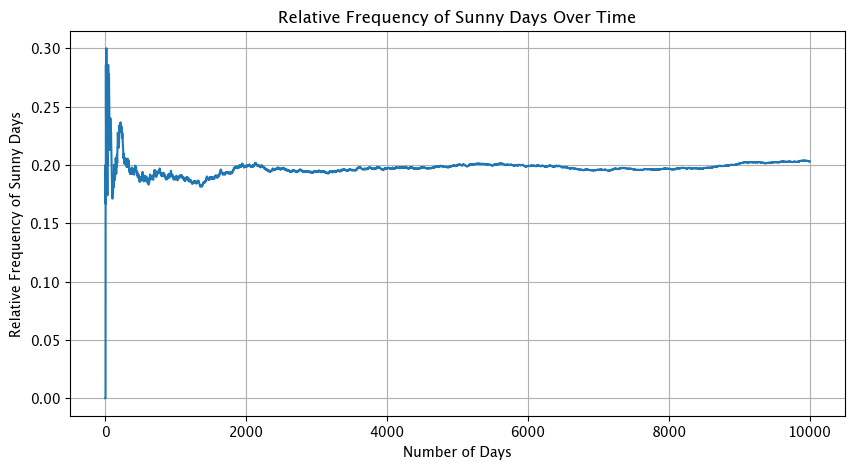

In [63]:
import matplotlib.pyplot as plt
number_of_forcasts = 10000
weather = np.random.rand(number_of_forcasts)

starting_weather = "Sunny"

def weather_forcast(starting_weather, weather):
    weather_results = np.zeros((2,2), dtype=int)  # row 0: Sunny, row 1: Rainy; col 0: Sunny, col 1: Rainy
    current_weather = starting_weather
    fraction = np.zeros(number_of_forcasts)
    for i, w in enumerate(weather):

        if current_weather == "Sunny":
            if w < 0.8:
                weather_results[0,0] = weather_results[0,0] + 1
                current_weather = "Sunny"
            else:
                weather_results[0,1] = weather_results[0,1] + 1
                current_weather = "Rainy"
        else:  # Rainy
            if w < 0.4:
                weather_results[1,0] = weather_results[1,0] + 1
                current_weather = "Sunny"
                
            else:
                weather_results[1,1] = weather_results[1,1] + 1
                current_weather = "Rainy"
        fraction[i] = weather_results[1,0] / sum(weather_results[:,0])
    return weather_results, fraction
weather_results, fraction = weather_forcast(starting_weather, weather)
rainy_to_sunny_prob = weather_results[1,0] / sum(weather_results[:,0])


print(weather_results)
print(rainy_to_sunny_prob)

plt.figure(figsize=(10,5))
plt.plot(range(1, number_of_forcasts+1), fraction)
plt.xlabel("Number of Days")
plt.ylabel("Relative Frequency of Sunny Days")
plt.title("Relative Frequency of Sunny Days Over Time")
plt.grid(True)
plt.show()


Exercise 3: Brownian bridge/Weiner process.

200
0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103


/var/folders/7s/x2b50n9s5z57ghgsc5m5nzhh0000gn/T/ipykernel_984/260770682.py:29: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


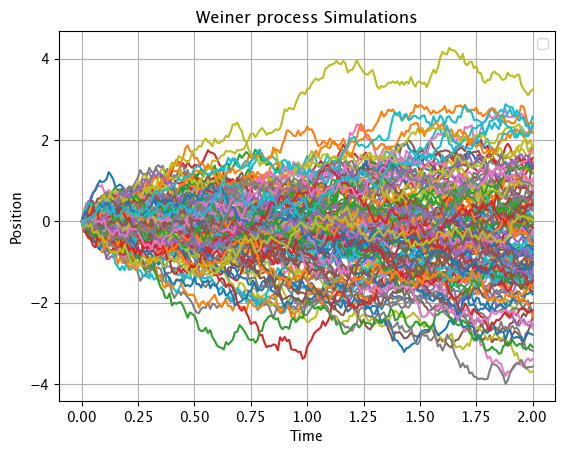

In [73]:
time = 2
step_length = 0.01
n_steps = int(time / step_length)
number_of_simulations = 120
print(len(range(n_steps)))

def brownian_motion(variance, mean, total_time=time, n_steps=n_steps):
    total_time = total_time
    n_steps = n_steps
    time_range = np.linspace(0, total_time, n_steps)
    position = np.zeros(n_steps + 1)  # +1 because we start at
    for i, t in enumerate(time_range):
        print(i)
        position[i+1] = position[i] + np.random.normal(mean, np.sqrt(variance))
    return position

# Optionally, print or plot
brownian_runs = np.zeros((number_of_simulations, n_steps+1))
time_range = np.linspace(0, time, n_steps + 1)

for sim in range(number_of_simulations):
    brownian_runs[sim, :] = brownian_motion(variance=step_length, mean=0)
    
    plt.plot(time_range, brownian_runs[sim])

plt.xlabel('Time')
plt.ylabel('Position')
plt.title('Weiner process Simulations')
plt.legend()
plt.grid(True)
plt.show()

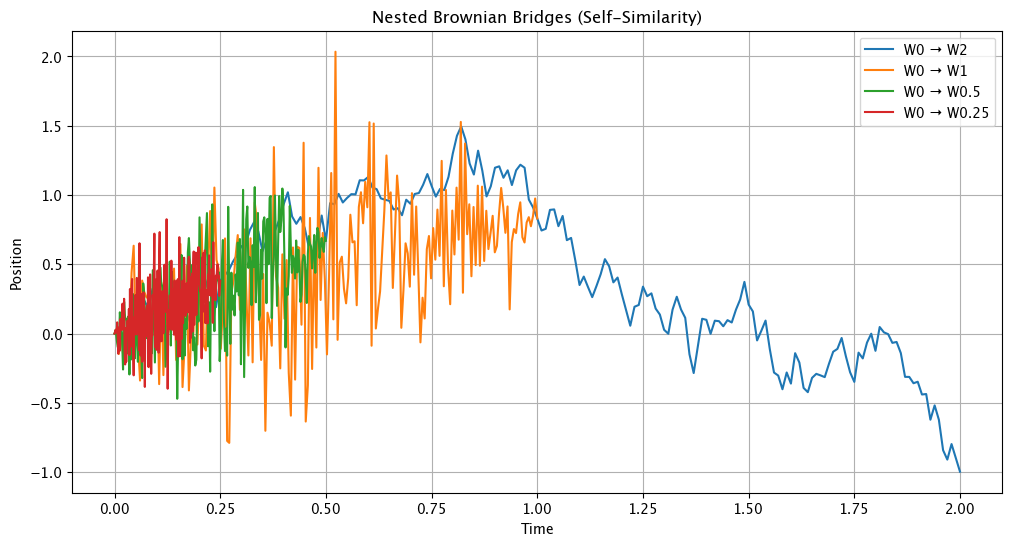

In [71]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Simulation parameters
# -----------------------------
T = 2           # total time
dt = 0.01       # time step
n_steps = int(T/dt)  # number of steps

# -----------------------------
# Generate standard Brownian motion
# -----------------------------
W = np.zeros(n_steps + 1)
for i in range(n_steps):
    W[i+1] = W[i] + np.random.normal(0, np.sqrt(dt))

# Extract intermediate points for nested bridges
W_quarter = W[n_steps // 8]   # t = 0.25
W_half    = W[n_steps // 4]   # t = 0.5
W1        = W[n_steps // 2]   # t = 1
W2        = W[-1]             # t = 2

# -----------------------------
# Function to simulate Brownian bridge
# -----------------------------
def brownian_bridge(t1, t2, a, b, N):
    t = np.linspace(t1, t2, N)
    B = np.zeros(N)
    B[0], B[-1] = a, b
    for i in range(1, N-1):
        mean = a + (t[i] - t1)/(t2 - t1) * (b - a)
        var  = (t2 - t[i]) * (t[i] - t1) / (t2 - t1)
        B[i] = np.random.normal(mean, np.sqrt(var))
    return t, B

# -----------------------------
# Generate nested Brownian bridges
# -----------------------------
t_W1, bridge_W1         = brownian_bridge(0, 1, 0, W1, n_steps)
t_half, bridge_half     = brownian_bridge(0, 0.5, 0, W_half, n_steps)
t_quarter, bridge_quarter = brownian_bridge(0, 0.25, 0, W_quarter, n_steps)

# -----------------------------
# Plot
# -----------------------------
t = np.linspace(0, T, n_steps + 1)
plt.figure(figsize=(12,6))
plt.plot(t, W, label='W0 → W2')
plt.plot(t_W1, bridge_W1, label='W0 → W1')
plt.plot(t_half, bridge_half, label='W0 → W0.5')
plt.plot(t_quarter, bridge_quarter, label='W0 → W0.25')
plt.xlabel('Time')
plt.ylabel('Position')
plt.title('Nested Brownian Bridges (Self-Similarity)')
plt.grid(True)
plt.legend()
plt.show()


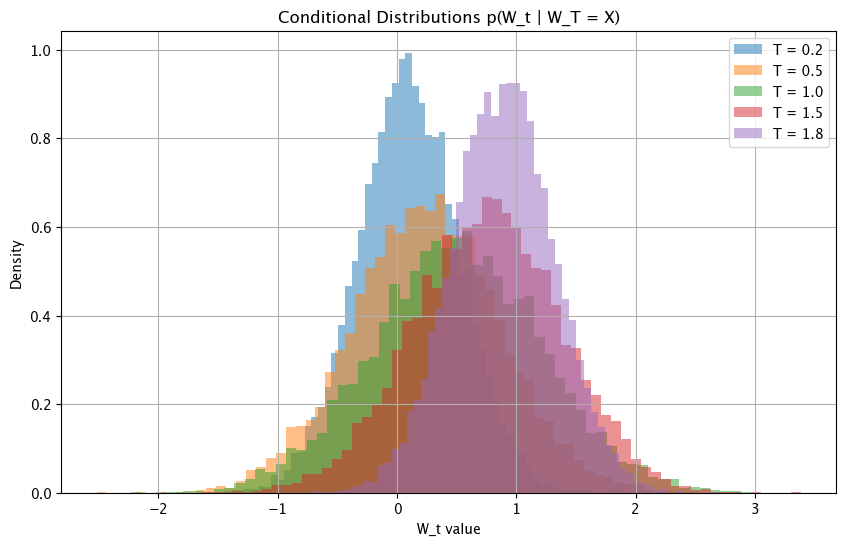

In [125]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
T = 2
X = 1
dt = 0.01
n_samples = 10000
times = [0.2, 0.5, 1.0, 1.5, 1.8]  # different times to check

# Simulate conditional distributions
plt.figure(figsize=(10, 6))

for t in times:
    mean = (t / T) * X
    var = t * (1 - t / T)
    samples = np.random.normal(mean, np.sqrt(var), n_samples)
    plt.hist(samples, bins=60, alpha=0.5, density=True, label=f"T = {t:.1f}")

plt.title("Conditional Distributions p(W_t | W_T = X)")
plt.xlabel("W_t value")
plt.ylabel("Density")
plt.legend()
plt.grid(True)
plt.show()

